# E51 - The Decline-Bias Root-Cause Round: is the down-drift a defect, or earned signal? (H464-H470)

**Author**: kj · **Round**: E51 (fair-well re-test) · **Campaign**: demographic-collapse

The shipped behavioural core carries a decline-bias defect register - DEF-1 (a secular down-drift on
every quantum channel), DEF-2 (a one-way dependency ratchet), DEF-3 (an antinatal-only norm well),
DEF-4 (rate constants calibrated only on collapse), DEF-6 (thin fertility-raising channels). This round
attacks those CAUSES at their structural root, not the recuperation symptom (DEF-5, whose bolt-on was
promotion-DECLINED at E50). The governing question for each is defect-vs-feature: is the down-drift an
artifact to symmetrise away, or the model correctly encoding that these societies are declining - so that
removing it makes the E41 2000-2023 backtest WORSE?

**This is the fair-well re-test.** A methodology re-review found the earlier round ruled DEF-6 (H468) a
non-selective confound using a MALFORMED parity well - the stiffness $a_P$ hand-set to 0.6 (not
curvature-matched to the shipped $k_{Pb}$), the low well anchored self-referentially to $\mathrm{PB\_SCALE\_ENS}$
(which inflated a 40x calibration break), and the root ordering scrambled for regions whose parity already
sits above the tip. The pre-registered FAIR form was never run. Here it is: the low well anchored at the
region's own unscaled baseline $\mathrm{PB0}$, $a_P$ curvature-matched per region, and an honest ordering
that leaves already-high-parity regions inert rather than wrong-signing them. H468 is re-graded from a
COMPUTED condition with both a GRAFT-CANDIDATE branch and a REMOVE branch reachable.

**The contrarian null.** A "defect" is presumed a correctly-fit FEATURE until a fix proves it IMPROVES the
backtest (lower recovery RMSE AND no worse $\chi^2/\mathrm{dof}$) WITHOUT (a) breaking the 2023 calibration
after a PB_SCALE re-solve ($< 5\times10^{-4}$), (b) letting Korea spuriously recover (R2 gate), or (c)
wrong-signing the decline regions. A fix that clears those bars is a GRAFT-CANDIDATE; one that does not is
REFUTED / INERT - earned honestly on the correct form.

**Discipline.** Every fix is a baseline-preserving notebook-local deviation (identically the shipped core
when its coefficient is off, asserted bit-for-bit across 8 regions). No `src/` is edited. Every verdict is
an `if/else` on a computed number, and each branch is shown reachable by a counterfactual self-test. The
expensive validated refits (DEF-4 probe, JOINT) are reused from `scratchpad/bias_results.json`; the
make-or-break adjudications - baseline, DEF-1, and the FAIR DEF-6 well - are re-run live so each verdict
COMPUTES from its pre-registered condition.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "GPU-58ae1f45-295c-681b-60ad-843265f52997")
import sys
sys.path.insert(0, "../src")
sys.path.insert(0, "../scratchpad")

import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from rich import print as rprint
from rich.table import Table
from rich.console import Console

# the pre-ported, baseline-preserving E41 backtest harness (Phase-0 research artifact)
from toy_bias_harness import (
    BiasModel, DATA, REGIONS, TIPP, PTWO, TFR_OBS, Y0, Y1,
    fit_params, residuals, tier2, run_backtest, chi2_at, calibration_drift,
)
import sci_demographic_collapse.emergent as em

console = Console()
rprint("[green]harness loaded[/green] - regions:", REGIONS)

2026-07-12 12:07:46.151 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


harness loaded - regions:
['USA', 'France', 'Germany', 'Italy', 'Japan', 'Korea', 'Poland', 'Israel']

## Reproducibility

In [2]:
import torch

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

## Configuration and pre-registered bars

The metric of record is the recovery MAGNITUDE - the RMS signed net-2000-2019 error over the four recovery
regions (Germany, Italy, Poland, Israel) - together with $\chi^2/\mathrm{dof}$. A KEEP requires recovery
RMSE to drop AND $\chi^2/\mathrm{dof}$ not to worsen. The R1 sign-miss count is reported for continuity but
flagged fragile: at the shipped drift the net 2000-2019 change is a small tempo-transient number and a
within-tolerance $\bar P$ difference can flip a borderline sign. All adjudication bars below are
pre-registered in `reports/def_biascorrection_fanout.md`.

In [3]:
RECOV = ["Germany", "Italy", "Poland", "Israel"]     # the four observed recoveries
OBS_NET = {r: float(TFR_OBS[r][2019] - TFR_OBS[r][Y0]) for r in REGIONS}

# pre-registered adjudication bars
TOL_CAL = 5e-4          # calibration drift after a PB_SCALE_ENS re-solve
TOL_INERT = 1e-3        # DEF-2 "bit-near-identical" series-delta bar
TOL_FROZEN = 1e-2       # DEF-3 "N frozen on the hindcast" series-delta bar
TOL_CHI2 = 0.02         # DEF-6 "does not worsen chi2/dof" slack
SHIFT_BAR = 0.20        # DEF-4 "material" rate-constant shift when Israel admitted
KOREA_OBS_2019 = 0.918  # R2 monotonicity anchor

# reuse the validated Phase-0 toy measurements (checkpointed to disk by toy_bias_run.py)
VAL = json.load(open("../scratchpad/bias_results.json"))

# consistency: our observed nets must match the validated table
assert all(abs(OBS_NET[r] - VAL["obs_net_2000_2019"][r]) < 1e-3 for r in REGIONS)

rprint("[bold]E51 configuration (fair-well re-test)[/bold]")
rprint(f"  Backtest window {Y0}-{Y1}; 8 regions; recovery set {RECOV}")
rprint("  Observed net 2000-2019: " + ", ".join(f"{r} {OBS_NET[r]:+.3f}" for r in REGIONS))
rprint(f"  Bars: cal drift < {TOL_CAL}, DEF-2 inert < {TOL_INERT}, DEF-3 frozen < {TOL_FROZEN}, "
       f"DEF-6 chi2 slack {TOL_CHI2}, rate shift < {SHIFT_BAR:.0%}, Korea R2 anchored at {KOREA_OBS_2019}")

E51 configuration (fair-well re-test)

Backtest window 2000-2023; 8 regions; recovery set ['Germany', 'Italy', 'Poland', 'Israel']

Observed net 2000-2019: USA -0.346, France -0.049, Germany +0.155, Italy +0.010, Japan -0.023, Korea -0.560, 
Poland +0.049, Israel +0.113

Bars: cal drift < 0.0005, DEF-2 inert < 0.001, DEF-3 frozen < 0.01, DEF-6 chi2 slack 0.02, rate shift < 20%, 
Korea R2 anchored at 0.918

## Baseline-preservation gate (bit-for-bit, 8 regions)

`BiasModel` subclasses the shipped `EmergentModel` and overrides `_estep_vec` with the fix toggles. With
every toggle OFF the override must reproduce the shipped step BIT-FOR-BIT - that identity is the guard that
keeps each deviation honest (any movement is attributable to the fix alone). We assert it directly on the
vector step across all 8 regions and four secular-clock values $t_n$, requiring a worst per-channel
difference of exactly 0.0 before trusting any downstream number.

In [4]:
m_base = BiasModel(data_dir=str(DATA))          # all toggles off == shipped
m_ship = em.EmergentModel(data_dir=str(DATA))   # the shipped core itself

rng = np.random.default_rng(SEED)
worst_ident = 0.0
for r in REGIONS:
    st = np.tile(np.array([0.5, 0.2, 1.5, 30.0, 0.5, em.NORM0[r], 0.0]), (8, 1))
    st = st + 0.01 * rng.standard_normal(st.shape)
    force = [0.0] * 9
    for tn in (-0.23, -0.10, 0.0, 0.05):
        a, _ = m_base._estep_vec(r, st.copy(), force, tn, 0.03, 0.0)
        b, _ = m_ship._estep_vec(r, st.copy(), force, tn, 0.03, 0.0)
        worst_ident = max(worst_ident, float(np.abs(a - b).max()))

assert worst_ident == 0.0, f"baseline-preservation broken: worst diff {worst_ident}"
rprint(f"[green]baseline-preservation PASS[/green] - worst per-channel diff "
       f"(8 regions x 4 tn) = {worst_ident} (bit-for-bit)")
rprint("Recorded src guard suite: 13/13 green (tests/test_hypothesis_guards.py), untouched by "
       "notebook-local fixes")

baseline-preservation PASS - worst per-channel diff (8 regions x 4 tn) = 0.0 (bit-for-bit)

Recorded src guard suite: 13/13 green (tests/test_hypothesis_guards.py), untouched by notebook-local fixes

## The FAIR two-child parity well - geometry, ordering semantics, curvature match, clean anchor

The malformed well was wrong three ways; the fair well fixes all three, and the fix is verified here before
any adjudication uses it.

**Ordering (fixed tip and plateau).** The two-child well is a proper bistable with the low well below the
unstable tip $\mathrm{tip}_P=1.72$ below the two-child plateau $P_{two}=2.0$. The low well of each region is
its OWN unscaled baseline parity $\mathrm{pb0}=\mathrm{PB0}$ (the same target the shipped linear relaxation
$\dot{\bar P}=k_{Pb}(\mathrm{PB0}-\bar P)$ pulls toward). The stability of the downward cubic
$\dot{\bar P}=-a_P(\bar P-\mathrm{pb0})(\bar P-\mathrm{tip}_P)(\bar P-P_{two})$ requires
$\mathrm{pb0}<\mathrm{tip}_P<P_{two}$; the largest root is always stable, the middle unstable, the smallest
stable. For a region whose baseline parity ALREADY sits at or above the tip (parity already high - there is
no lower basin to sit in and no upward two-child cascade to trigger) placing a fixed tip below it would
invert the ordering and spuriously pull it up or down. The honest semantics: **the well is a genuine
bistable only for regions with $\mathrm{pb0}<\mathrm{tip}_P$; for a region already at/above the tip it
degenerates to the shipped linear relaxation - inert, never a mis-ordering wrong-sign.** With the campaign's
data-derived PB0, the active set is exactly {Korea, Italy, Poland}; USA, France, Germany, Japan and Israel
are already above the tip and inert.

**Stiffness (curvature-matched, not hand-set).** Near the low well the cubic linearizes to
$\dot{\bar P}\approx -a_P(\mathrm{pb0}-\mathrm{tip}_P)(\mathrm{pb0}-P_{two})(\bar P-\mathrm{pb0})$, a linear
restoring rate $a_P(\mathrm{tip}_P-\mathrm{pb0})(P_{two}-\mathrm{pb0})$. Setting this equal to the shipped
$k_{Pb}=0.05$ gives

$$a_P^{(r)}=\frac{k_{Pb}}{(\mathrm{tip}_P-\mathrm{pb0}_r)(P_{two}-\mathrm{pb0}_r)}.$$

So near the low well the fair form is INDISTINGUISHABLE from the shipped linear relaxation - the ONLY
difference from shipped is the nonlinear cascade if $\bar P$ crosses the tip. The malformed hand-set
$a_P=0.6$ was an arbitrary quantum-softener; the curvature match removes that confound.

**Anchor (clean, not self-referential).** Anchoring the low well at the unscaled PB0 - not at
$\mathrm{PB0}\cdot\mathrm{PB\_SCALE\_ENS}$ - means the fixed point does not move with the parity rescale, so
`calibrate_ens` converges the same way it does for DEF-2/DEF-3. The secular and forcing terms stay additive
(identically the shipped $-k_{Pb}\,\mathrm{secPb}\cdot100\,t_n+k_{Pb}g_{Pb}f_{Pb}$).

In [5]:
m6_probe = BiasModel(data_dir=str(DATA), fix={"parity_well": True})
kPb = em.PARAMS["kPb"]

def dPb_fair(r, x):
    # fair-well dPb at parity x (tn=0, zero forcing), recovered from the clipped step
    st = np.array([[0.5, 0.2, x, 30.0, 0.5, em.NORM0[r], 0.0]])
    out, _ = m6_probe._estep_vec(r, st, [0.0] * 9, 0.0, 0.0, 0.0)
    return (out[0, 2] - x) / 0.25

def dPb_ship(r, x):
    st = np.array([[0.5, 0.2, x, 30.0, 0.5, em.NORM0[r], 0.0]])
    out, _ = m_ship._estep_vec(r, st, [0.0] * 9, 0.0, 0.0, 0.0)
    return (out[0, 2] - x) / 0.25

eps = 1e-4
t = Table(title="Fair-well geometry (per region)")
for c in ("region", "pb0", "active", "aP", "near-well rate", "dPb(pb0)", "anchor |fair-ship|"):
    t.add_column(c)
active_regs, worst_fp, worst_rate, worst_anchor = [], 0.0, 0.0, 0.0
for r in REGIONS:
    pb0 = m6_probe.PB0[r]
    active = pb0 < TIPP
    aP = kPb / ((TIPP - pb0) * (PTWO - pb0)) if active else float("nan")
    rate = -(dPb_fair(r, pb0 + eps) - dPb_fair(r, pb0 - eps)) / (2 * eps)   # near-well restoring rate
    fp = dPb_fair(r, pb0)                                                    # fixed-point residual
    anchor = em.PB_SCALE_ENS[r] * pb0                                        # the calibrated 2023 anchor
    dresid = abs(dPb_fair(r, anchor) - dPb_ship(r, anchor))                  # no spurious motion vs shipped
    if active:
        active_regs.append(r)
    worst_fp = max(worst_fp, abs(fp))
    if active:
        worst_rate = max(worst_rate, abs(rate - kPb))
    worst_anchor = max(worst_anchor, dresid)
    t.add_row(r, f"{pb0:.3f}", str(active), f"{aP:.3f}" if active else "-",
              f"{rate:.4f}", f"{fp:+.1e}", f"{dresid:.1e}")
console.print(t)

# geometry asserts: exact fixed point at the well bottom, curvature-matched rate == kPb, no spurious motion
assert worst_fp < 1e-9, f"well bottom not a fixed point: {worst_fp}"
assert worst_rate < 1e-6, f"curvature not matched to kPb: {worst_rate}"
assert worst_anchor < 1e-3, f"fair well adds spurious motion at the 2023 anchor: {worst_anchor}"
rprint(f"[green]fair-well geometry PASS[/green] - active set {active_regs}; "
       f"fixed-point residual < {worst_fp:.0e}, near-well rate == kPb (max dev {worst_rate:.0e}), "
       f"anchor motion == shipped (max {worst_anchor:.0e})")
rprint("[dim]inert regions (parity already >= tip) revert to the shipped linear relaxation - "
       "no lower basin, no cascade, no wrong-sign[/dim]")

                           Fair-well geometry (per region)                           
┏━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ region  ┃ pb0   ┃ active ┃ aP    ┃ near-well rate ┃ dPb(pb0) ┃ anchor |fair-ship| ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ USA     │ 1.941 │ False  │ -     │ 0.0500         │ +0.0e+00 │ 0.0e+00            │
│ France  │ 2.000 │ False  │ -     │ 0.0500         │ +0.0e+00 │ 0.0e+00            │
│ Germany │ 1.803 │ False  │ -     │ 0.0500         │ +0.0e+00 │ 0.0e+00            │
│ Italy   │ 1.671 │ True   │ 3.088 │ 0.0500         │ +0.0e+00 │ 8.0e-04            │
│ Japan   │ 1.756 │ False  │ -     │ 0.0500         │ +0.0e+00 │ 0.0e+00            │
│ Korea   │ 1.253 │ True   │ 0.143 │ 0.0500         │ +0.0e+00 │ 2.1e-05            │
│ Poland  │ 1.402 │ True   │ 0.263 │ 0.0500         │ +0.0e+00 │ 5.5e-04            │
│ Israel  │ 3.152 │ False  │ -     │ 0.0500         │ +0.0e+00 │ 0.0e+00            │
└─────────┴───────┴────────┴───────┴────────────────┴──────────┴────────────────────┘

fair-well geometry PASS - active set ['Italy', 'Korea', 'Poland']; fixed-point residual < 0e+00, near-well rate == 
kPb (max dev 3e-08), anchor motion == shipped (max 8e-04)

inert regions (parity already >= tip) revert to the shipped linear relaxation - no lower basin, no cascade, no 
wrong-sign

## Validated Phase-0 toy results (reused where inexpensive)

The full DEF-4 probe and the JOINT sweep were run once and checkpointed
(`toy_bias_run.py` → `bias_results.json`). The DEF-6 rows in that file were measured on the MALFORMED well
and are SUPERSEDED here by the live fair-well re-run below; the table is shown for provenance only.

In [6]:
def _row(key):
    d = VAL.get(key, {})
    return (d.get("chi2_dof"), d.get("n_R1"), d.get("recovery_rmse"),
            d.get("korea_2019"), d.get("cal_drift_after_resolve"))

t = Table(title="Validated toy measurements (DEF-6 / JOINT rows on the MALFORMED well - superseded live)")
for c in ("config", "chi2/dof", "R1", "recovery RMSE", "Korea 2019", "cal drift (post-resolve)"):
    t.add_column(c)
rows = [
    ("baseline (shipped)", "baseline"),
    ("DEF-1a zero-secular (no refit)", "def1a_zero_secular_norefit"),
    ("DEF-1b free bounds (up allowed)", "def1b_free_bounds"),
    ("DEF-2 signed dependency", "def2_signed_dep"),
    ("DEF-3 tri-well + Israel", "def3_triwell_israel"),
    ("DEF-6 MALFORMED well (superseded)", "def6_parity_well"),
    ("JOINT MALFORMED (superseded)", "joint_all_structural"),
]
for label, key in rows:
    c2, nr1, rm, k19, cal = _row(key)
    t.add_row(label, str(c2), str(nr1), str(rm), str(k19), str(cal))
console.print(t)
rprint("DEF-4 rate-refit probe (hold-Israel-out): "
       + ", ".join(f"{k} shift {VAL['def4_rate_refit']['israel_velocity_shift'][k]}"
                   for k in ("kC", "decl", "gS_C", "kTau")))

            Validated toy measurements (DEF-6 / JOINT rows on the MALFORMED well - superseded live)            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ config                            ┃ chi2/dof ┃ R1   ┃ recovery RMSE ┃ Korea 2019 ┃ cal drift (post-resolve) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ baseline (shipped)                │ 3.684    │ 6    │ 0.124         │ 0.829      │ None                     │
│ DEF-1a zero-secular (no refit)    │ 8.393    │ None │ None          │ None       │ None                     │
│ DEF-1b free bounds (up allowed)   │ 3.221    │ 4    │ 0.2653        │ 0.835      │ None                     │
│ DEF-2 signed dependency           │ 3.684    │ 6    │ 0.1236        │ 0.829      │ 1e-06                    │
│ DEF-3 tri-well + Israel           │ 3.681    │ 6    │ 0.1238        │ 0.828      │ 1e-06                    │
│ DEF-6 MALFORMED well (superseded) │ 4.26     │ 3    │ 0.0617        │ 0.781      │ 0.020254                 │
│ JOINT MALFORMED (superseded)      │ 7.784    │ 4    │ 0.0473        │ 0.683      │ 0.015219                 │
└───────────────────────────────────┴──────────┴──────┴───────────────┴────────────┴──────────────────────────┘

DEF-4 rate-refit probe (hold-Israel-out): kC shift 0.0, decl shift 0.0, gS_C shift 0.0, kTau shift 0.00095

## Verdict machinery - the reachable-branch discipline

Every verdict below is the return value of a pure adjudication function evaluated on a computed number.
Immediately after each real call we exercise the function on a counterfactual input that drives it into the
OPPOSITE branch, and assert it returns the KEEP-side label - proving the branch is reachable, not dead code
that hard-codes a foregone REFUTED.

In [7]:
VERDICTS = {}


def record(h, title, verdict, metric, note):
    VERDICTS[h] = dict(title=title, verdict=verdict, metric=metric, note=note)
    rprint(f"[bold]{h}[/bold] -> [yellow]{verdict}[/yellow]  {metric}")
    return verdict


def net_and_rmse(RUNS):
    net = {r: float(RUNS[r]["TFR"][2019 - Y0] - RUNS[r]["TFR"][0]) for r in REGIONS}
    rmse = float(np.sqrt(np.mean([(net[r] - OBS_NET[r]) ** 2 for r in RECOV])))
    return net, rmse

## H464 - DEF-1: the secular down-drift is a feature, not a glide-path artifact (make-or-break)

The four secular constants all point fertility DOWN. In `_estep_vec` they enter as

$$C_{eq}=C_0+g_{S\to C}(S-S_0)+g_{qC}\,q+f_C-\mathrm{secC}\cdot100\,t_n,\qquad
\dot{\bar P}=k_{Pb}\big(PB_0+g_{Pb}f_{Pb}-\mathrm{secPb}\cdot100\,t_n-\bar P\big),$$
$$\dot\tau=k_\tau\big(\tau^\ast+g_\tau(S_0-S)+f_\tau+\mathrm{secTau}\cdot100\,t_n-\tau\big),\qquad
\dot S=k_S(S_0+f_S-\mathrm{dep\_pen}-S)-\mathrm{secS},$$

with clock $t_n=(\text{year}-2023)/100$. **Fix under test**: set $\mathrm{secC}=\mathrm{secPb}=\mathrm{secTau}
=\mathrm{secS}=0$, or widen the fit bounds to admit up-drift (negative) and refit. **Null (feature)**: the
WLS fit, free to choose, sets the drift STRONGER-down, so removing it makes the backtest worse.

**Pass bar**: KEEP iff zeroing OR the sign-free refit lowers $\chi^2/\mathrm{dof}$ below baseline AND does
not raise R1, with calibration and Korea intact. REFUTED-AS-DEFECT iff zeroing raises $\chi^2/\mathrm{dof}$
or the free fit still selects positive (down) secC/secPb. This is the only defect the backtest directly
adjudicates, so it settles the omnibus defect-vs-feature question - it runs first.

**Qualification (POOLED-OBJECTIVE-CONDITIONAL).** The free-bounds fit minimises a pooled objective in which
the large collapses dominate; the "earned-signal" claim is conditional on that objective. As a cheap check
we also run a RECOVERY-WEIGHTED refit (recovery residuals up-weighted 5x) and report whether even THAT
objective still rails the secular terms down. If it does, the earned-signal claim strengthens; if it selects
up-drift, we record the objective-dependence.

In [8]:
t0 = time.time()

# --- baseline refit (live, standard bounds) ---
P_base, chi2_base, N_base = fit_params(m_base)
r1_base, r2_base, RUNS_base = tier2(m_base, P_base)
net_base, rmse_base = net_and_rmse(RUNS_base)

# consistency guard: the live baseline must reproduce the disk-checkpointed baseline (mirror OBS_NET guard)
assert abs(chi2_base - VAL["baseline"]["chi2_dof"]) < 0.05, \
    f"live baseline chi2 {chi2_base:.3f} != disk {VAL['baseline']['chi2_dof']}"
assert abs(rmse_base - VAL["baseline"]["recovery_rmse"]) < 0.01, \
    f"live baseline recovery RMSE {rmse_base:.4f} != disk {VAL['baseline']['recovery_rmse']}"

# --- DEF-1a: zero all four secular terms, no refit (cost of simply removing the drift) ---
m0 = BiasModel(data_dir=str(DATA))
m0.P = dict(m0.P)
m0.P.update(secC=0.0, secPb=0.0, secTau=0.0, secS=0.0)
rs0 = residuals(m0, dict(secC=0.0, secPb=0.0, secTau=0.0, kTau=em.PARAMS["kTau"]))
chi2_zero = float(np.sum(rs0 ** 2)) / (len(rs0) - 4)

# --- DEF-1b: widen bounds to admit up-drift; does the fit still pick down? ---
FREE = {"secC": (-0.01, 0.01), "secPb": (-0.02, 0.02), "secTau": (-0.06, 0.06),
        "secS": (-0.01, 0.01), "kTau": (0.01, 0.3)}
P_free, chi2_free, _ = fit_params(m_base, bounds=FREE)
r1_free, r2_free, RUNS_free = tier2(m_base, P_free)
net_free, rmse_free = net_and_rmse(RUNS_free)

rprint(f"baseline: chi2/dof {chi2_base:.3f}, R1 {len(r1_base)}, recovery RMSE {rmse_base:.4f}, "
       f"Korea19 {r2_base['model_2019']} (live == disk {VAL['baseline']['chi2_dof']} guard PASS)")
rprint(f"DEF-1a zero-secular (no refit): chi2/dof {chi2_zero:.3f}")
rprint(f"DEF-1b free-bounds fit: secC {P_free['secC']:+.4f}, secPb {P_free['secPb']:+.4f}, "
       f"secTau {P_free['secTau']:+.4f}, secS {P_free['secS']:+.4f}; chi2/dof {chi2_free:.3f}; "
       f"recovery RMSE {rmse_free:.4f}")

baseline: chi2/dof 3.684, R1 6, recovery RMSE 0.1238, Korea19 0.829 (live == disk 3.684 guard PASS)

DEF-1a zero-secular (no refit): chi2/dof 8.393

DEF-1b free-bounds fit: secC +0.0100, secPb +0.0122, secTau +0.0195, secS +0.0100; chi2/dof 3.221; recovery RMSE 
0.2654

In [9]:
# --- recovery-weighted secular refit (POOLED-OBJECTIVE-CONDITIONAL cheap check) ---
W_RECOV = 5.0
keysF = list(FREE)

def weighted_obj(x):
    xc = np.array([np.clip(v, *FREE[k]) for v, k in zip(x, keysF)])
    pen = 1e3 * float(np.sum((x - xc) ** 2))
    rs, tags, _ = residuals(m_base, dict(zip(keysF, xc)), detail=True)
    w = np.array([W_RECOV if tg[0] in RECOV else 1.0 for tg in tags])
    rw = rs * np.sqrt(w)
    a, d = np.abs(rw), 1.345
    return float(np.sum(np.where(a <= d, 0.5 * rw ** 2, d * (a - 0.5 * d)))) + pen

x0F = np.array([em.PARAMS.get(k, 0.0) for k in keysF])
resW = minimize(weighted_obj, x0F, method="Nelder-Mead",
                options=dict(maxiter=200, xatol=1e-4, fatol=1e-3))
P_wt = {k: float(np.clip(v, *FREE[k])) for k, v in zip(keysF, resW.x)}
wt_picks_up = (P_wt["secC"] < 0) or (P_wt["secPb"] < 0)
rprint(f"recovery-weighted (5x) free refit: secC {P_wt['secC']:+.4f}, secPb {P_wt['secPb']:+.4f}, "
       f"secTau {P_wt['secTau']:+.4f}, secS {P_wt['secS']:+.4f}")
rprint(f"  -> even up-weighting the recoveries, the fit selects "
       f"{'UP-drift (objective-dependent!)' if wt_picks_up else 'DOWN-drift (earned-signal strengthened)'}")
rprint(f"[dim]elapsed {time.time()-t0:.0f}s[/dim]")

recovery-weighted (5x) free refit: secC +0.0049, secPb +0.0122, secTau +0.0051, secS +0.0075

-> even up-weighting the recoveries, the fit selects DOWN-drift (earned-signal strengthened)

elapsed 422s

In [10]:
def adjudicate_h464(chi2_zero, chi2_base, secC_free, secPb_free, chi2_free, n_r1_free, n_r1_base):
    zeroing_helps = chi2_zero < chi2_base                      # removing the drift lowers chi2?
    free_picks_up = (secC_free < 0) or (secPb_free < 0)        # fit chooses UP-drift when allowed?
    free_improves = free_picks_up and (chi2_free < chi2_base) and (n_r1_free <= n_r1_base)
    if zeroing_helps or free_improves:
        return "KEEP/PROMOTE"
    return "REFUTED-AS-DEFECT"


v464 = adjudicate_h464(chi2_zero, chi2_base, P_free["secC"], P_free["secPb"],
                       chi2_free, len(r1_free), len(r1_base))
# reachability: had zeroing lowered chi2, the KEEP branch fires
assert adjudicate_h464(chi2_base - 1.0, chi2_base, +0.01, +0.01, chi2_base, 0, len(r1_base)) == "KEEP/PROMOTE"
# reachability: had the free fit selected up-drift with a lower chi2, KEEP also fires
assert adjudicate_h464(chi2_zero, chi2_base, -0.005, +0.01, chi2_base - 0.2, 0, len(r1_base)) == "KEEP/PROMOTE"

wt_txt = ("the recovery-weighted refit ALSO rails secC/secPb down" if not wt_picks_up
          else f"the recovery-weighted refit selects up-drift (secC {P_wt['secC']:+.3f}) - objective-dependent")
record("H464", "DEF-1: secular down-drift is a feature (make-or-break, POOLED-OBJECTIVE-CONDITIONAL)", v464,
       f"zeroing chi2/dof {chi2_zero:.2f} vs baseline {chi2_base:.2f} ({chi2_zero/chi2_base:.1f}x worse); "
       f"free-bounds fit picks secC {P_free['secC']:+.3f}, secPb {P_free['secPb']:+.3f} (both DOWN), "
       f"chi2 {chi2_free:.2f} but recovery RMSE {rmse_free:.3f} (worse than {rmse_base:.3f}); {wt_txt}",
       "the earned-signal claim is POOLED-OBJECTIVE-CONDITIONAL: on the pooled WLS objective the fit set "
       "free pins the drift maximally DOWN and makes the recoveries worse; " + wt_txt + ", so the "
       "down-drift is correctly-fit signal on both the pooled and the recovery-weighted objective. A "
       "monotone term of any sign cannot make a recovery's interior trough-then-rise, so DEF-1 is "
       "orthogonal to the missed recoveries regardless")

H464 -> REFUTED-AS-DEFECT  zeroing chi2/dof 8.39 vs baseline 3.68 (2.3x worse); free-bounds fit picks secC +0.010, 
secPb +0.012 (both DOWN), chi2 3.22 but recovery RMSE 0.265 (worse than 0.124); the recovery-weighted refit ALSO 
rails secC/secPb down

'REFUTED-AS-DEFECT'

## H465 - DEF-2: the signed dependency dividend is inert on the backtest (INERT-ON-HINDCAST)

The age-structure feedback is a one-way ratchet: $\mathrm{dep\_pen}=\mathrm{dep\_fb}\cdot\max(\mathrm{dep}-
\mathrm{dep}_0,0)$ keeps only the aging headwind. **Fix under test**: drop the clip for the symmetric
dividend $\mathrm{dep\_pen}=\mathrm{dep\_fb}\cdot(\mathrm{dep}-\mathrm{dep}_0)$, so a younging pyramid can
tail-wind fertility. **Null (inert)**: over 2000-2023 every region's pyramid only ages, so $\mathrm{dep}>
\mathrm{dep}_0$ every year and the clipped and signed forms are numerically identical on the gate.

**Pass bar**: KEEP iff the signed dividend changes $\chi^2/\mathrm{dof}$ or a recorded verdict.
INERT-ON-HINDCAST iff bit-near-identical on the aging window - the dividend branch is inexercisable when the
pyramid only ages (it becomes an algebraic identity, $\max(\mathrm{dep}-\mathrm{dep}_0,0)=\mathrm{dep}-
\mathrm{dep}_0$), so the clip is NOT disproven; the forward asymmetry is real but deferred. We re-run the
series delta live.

In [11]:
m_dep = BiasModel(data_dir=str(DATA), fix={"dep_signed": True})
delta_dep = max(float(np.abs(run_backtest(m_base, r)["TFR"] - run_backtest(m_dep, r)["TFR"]).max())
                for r in REGIONS)
chi2_dep = VAL["def2_signed_dep"]["chi2_dof"]     # validated refit optimum
cal_dep = VAL["def2_signed_dep"]["cal_drift_after_resolve"]
rprint(f"DEF-2 signed-vs-clipped max series delta {delta_dep:.6f} (bar {TOL_INERT}); "
       f"refit chi2/dof {chi2_dep} vs baseline {chi2_base:.3f}; cal drift {cal_dep}")


def adjudicate_h465(series_delta, chi2_fix, chi2_base, tol_move, tol_chi2=1e-2):
    moves = (series_delta > tol_move) or (abs(chi2_fix - chi2_base) > tol_chi2)
    return "KEEP" if moves else "INERT-ON-HINDCAST"


v465 = adjudicate_h465(delta_dep, chi2_dep, chi2_base, TOL_INERT)
assert adjudicate_h465(0.05, chi2_dep, chi2_base, TOL_INERT) == "KEEP"   # reachable KEEP

record("H465", "DEF-2: signed dependency dividend is inert on the hindcast", v465,
       f"max series delta {delta_dep:.6f} < {TOL_INERT}; refit chi2/dof {chi2_dep} = baseline; "
       f"cal drift {cal_dep} after re-solve",
       "INERT-ON-HINDCAST, not disproven: over an aging window dep>dep0 always, so the clip reduces to the "
       "algebraic identity max(dep-dep0,0)=(dep-dep0) and the dividend branch is inexercisable in-sample. "
       "The forward-run asymmetry (a younging pyramid tail-winding fertility) is real but deferred - it "
       "moves no backtest number, so it is not a shipped fix now")

DEF-2 signed-vs-clipped max series delta 0.000679 (bar 0.001); refit chi2/dof 3.684 vs baseline 3.684; cal drift 
1e-06

H465 -> INERT-ON-HINDCAST  max series delta 0.000679 < 0.001; refit chi2/dof 3.684 = baseline; cal drift 1e-06 
after re-solve

'INERT-ON-HINDCAST'

## H466 - DEF-3: the pronatal tri-well is inert on the hindcast (INERT-ON-HINDCAST)

The norm channel is antinatal-only: the cubic double-well $\dot N=-a_N(N-N_{lo})(N-\theta_N)(N-N_{hi})+f_N$
has a childfree lock-in and an untrapped low well but no stable well below $N_{lo}$. **Fix under test**:
the quintic tri-well $\dot N=-a_N c_N (N-N_{pro})(N-t_{pro})(N-N_{lo})(N-\theta_N)(N-N_{hi})+f_N$ with a
pronatal basin $N_{pro}=0.02$ (Israel/Haredi), optionally re-anchoring Israel to it. **Null (inert)**: each
region starts snapped to its well, so $N$ is a frozen fixed point on the hindcast; a third well changes the
potential but not the frozen state.

**Pass bar (backtest)**: INERT-ON-HINDCAST iff $N$ stays frozen (at $N=\mathrm{NORM0}$, $f_N=0$) and the
series is unchanged - the tri-well is inexercisable when nothing forces the norm off its fixed point, NOT
disproven; the only place it can earn keep is a FORWARD norm-lever durability verdict, which the hindcast
cannot adjudicate. We re-run the series delta and the Israel-anchor probe live.

In [12]:
m_tri = BiasModel(data_dir=str(DATA), fix={"triwell": True, "israel_pronatal": True})
delta_tri = max(float(np.abs(run_backtest(m_base, r)["TFR"] - run_backtest(m_tri, r)["TFR"]).max())
                for r in REGIONS)
# Israel re-anchor WITHOUT the tri-well: 0.02 is not a fixed point of the cubic -> N drifts up
m_isr_only = BiasModel(data_dir=str(DATA), fix={"israel_pronatal": True})
net_isr_only = float(run_backtest(m_isr_only, "Israel")["TFR"][2019 - Y0]
                     - run_backtest(m_isr_only, "Israel")["TFR"][0])
net_isr_tri = float(run_backtest(m_tri, "Israel")["TFR"][2019 - Y0]
                    - run_backtest(m_tri, "Israel")["TFR"][0])
chi2_tri = VAL["def3_triwell_israel"]["chi2_dof"]
cal_tri = VAL["def3_triwell_israel"]["cal_drift_after_resolve"]
rprint(f"DEF-3 tri-well max series delta {delta_tri:.5f} (bar {TOL_FROZEN}); refit chi2/dof {chi2_tri} "
       f"vs baseline {chi2_base:.3f}; cal drift {cal_tri} after re-solve")
rprint(f"Israel re-anchor: WITHOUT tri-well net {net_isr_only:+.3f} (0.02 not a fixed point -> drifts), "
       f"WITH tri-well net {net_isr_tri:+.3f} (sits still)")


def adjudicate_h466(series_delta, chi2_fix, chi2_base, tol_frozen, tol_chi2=1e-2):
    inert = (series_delta < tol_frozen) and (abs(chi2_fix - chi2_base) < tol_chi2)
    return "INERT-ON-HINDCAST" if inert else "MOVES-ESCALATE"


v466 = adjudicate_h466(delta_tri, chi2_tri, chi2_base, TOL_FROZEN)
assert adjudicate_h466(0.05, chi2_tri, chi2_base, TOL_FROZEN) == "MOVES-ESCALATE"   # reachable other branch

record("H466", "DEF-3: pronatal tri-well is inert on the hindcast", v466,
       f"tri-well series delta {delta_tri:.5f} < {TOL_FROZEN}; refit chi2/dof {chi2_tri} = baseline; "
       f"Israel with-well net {net_isr_tri:+.3f} ~ baseline (frozen at NORM0)",
       "INERT-ON-HINDCAST, not disproven: N starts snapped to NORM0 and nothing forces it in-sample "
       "(fN=0), so the third well changes the potential but not the frozen state and moves no backtest "
       "number. It is the right structural home for a durable pronatal cascade, but its relevance is a "
       "FORWARD norm-lever durability verdict, deferred - and by Occam prefer the single norm-layer well "
       "over the DEF-6 parity layer")

DEF-3 tri-well max series delta 0.00483 (bar 0.01); refit chi2/dof 3.681 vs baseline 3.684; cal drift 1e-06 after 
re-solve

Israel re-anchor: WITHOUT tri-well net -0.023 (0.02 not a fixed point -> drifts), WITH tri-well net +0.005 (sits 
still)

H466 -> INERT-ON-HINDCAST  tri-well series delta 0.00483 < 0.01; refit chi2/dof 3.681 = baseline; Israel with-well 
net +0.005 ~ baseline (frozen at NORM0)

'INERT-ON-HINDCAST'

## H467 - DEF-4: recovery-velocity refit holding Israel out (subsumed probe)

The dynamic rate constants $\{k_C,\mathrm{decl},g_{S\to C},k_\tau\}$ were fit in E19 on the 7 collapsing
regions; Israel is a placed point, never a recovery-velocity constraint. **Probe**: refit those constants on
all 8 regions vs the 7 non-Israel regions and compare. **Null (subsumed)**: without a restoring term the
system cannot rise for any rate constants, and Israel's $C_0=0.97$ sits ABOVE the coupling trap (the decl
term is identically 0 there), so the fit is near-invariant to holding Israel in or out.

**Pass bar**: escalate iff a rate constant shifts materially ($>20\%$) when Israel is admitted AND that
lowers the recovery $\chi^2$. SUBSUMED iff the shifts are small. We adjudicate on the validated probe (an
expensive double Nelder-Mead over the rate params, reused from disk), and additionally report the refit
$\chi^2/\mathrm{dof}$ and the finding that BOTH fits rail $\mathrm{decl}\to0$ (the backtest wants the
coupling trap OFF) - which bounds how far a 23-year hindcast can certify the FORWARD decline-bias.

In [13]:
d4 = VAL["def4_rate_refit"]
shifts_rel = {}
for k in ("kC", "decl", "gS_C", "kTau"):
    denom = d4["hold_israel_out"][k]
    shift = abs(d4["israel_velocity_shift"][k])
    shifts_rel[k] = (shift / denom) if denom != 0 else (0.0 if shift == 0 else float("inf"))
max_shift = max(v for v in shifts_rel.values() if np.isfinite(v))
rprint("DEF-4 relative rate-constant shift when Israel admitted: "
       + ", ".join(f"{k} {v:.1%}" if np.isfinite(v) else f"{k} n/a" for k, v in shifts_rel.items()))

# the refit chi2/dof at the decl->0 rate constants (both all-8 and hold-out rail decl to 0)
chi2_decl0, _ = chi2_at(m_base, d4["all8"])
decl_all8, decl_hold = d4["all8"]["decl"], d4["hold_israel_out"]["decl"]
rprint(f"both rate refits rail decl -> 0 (all8 decl={decl_all8}, hold-out decl={decl_hold}); "
       f"refit chi2/dof at those constants {chi2_decl0:.3f} vs baseline {chi2_base:.3f}")


def adjudicate_h467(shifts_rel, bar):
    material = any(v > bar for v in shifts_rel.values())
    return "ESCALATE" if material else "SUBSUMED"


v467 = adjudicate_h467(shifts_rel, SHIFT_BAR)
assert adjudicate_h467({"kTau": 0.30}, SHIFT_BAR) == "ESCALATE"   # reachable ESCALATE

record("H467", "DEF-4: recovery-velocity refit is subsumed", v467,
       f"max relative shift {max_shift:.1%} < {SHIFT_BAR:.0%} (only kTau moves, {shifts_rel['kTau']:.1%}); "
       f"both rate refits rail decl->0 (chi2/dof {chi2_decl0:.2f} at those constants)",
       "Israel as a recovery-velocity constraint moves nothing material (its C0=0.97 sits above the "
       "coupling trap and does not constrain the trap constants). Both the all-8 and hold-Israel-out rate "
       f"refits drive decl->0 (chi2/dof {chi2_decl0:.2f}) - the backtest wants the coupling trap OFF, which "
       "bounds how far a 23-year hindcast can certify the forward decline-bias: an identifiability caveat "
       "downstream of DEF-5, not an independent fix the backtest can act on")

DEF-4 relative rate-constant shift when Israel admitted: kC 0.0%, decl 0.0%, gS_C 0.0%, kTau 1.7%

both rate refits rail decl -> 0 (all8 decl=0.0, hold-out decl=0.0); refit chi2/dof at those constants 6.869 vs 
baseline 3.684

H467 -> SUBSUMED  max relative shift 1.7% < 20% (only kTau moves, 1.7%); both rate refits rail decl->0 (chi2/dof 
6.87 at those constants)

'SUBSUMED'

## H468 - DEF-6: the FAIR two-child parity well, re-adjudicated

**Fix under test (fair form)**: replace the linear parity relaxation with the two-child bistable well
$$\dot{\bar P}=-a_P(\bar P-\mathrm{pb0})(\bar P-\mathrm{tip}_P)(\bar P-P_{two})-k_{Pb}\,\mathrm{secPb}\cdot
100\,t_n+k_{Pb}g_{Pb}f_{Pb},$$
with the low well at the region's own UNSCALED baseline $\mathrm{pb0}=\mathrm{PB0}$, tip $\mathrm{tip}_P=
1.72$, plateau $P_{two}=2.0$, and $a_P$ curvature-matched (verified above). Active on {Korea, Italy, Poland}
(baseline below the tip); inert on the five regions already at/above the tip. The tip
$\mathrm{tip}_P=1.72$ and plateau $P_{two}=2.0$ are CARRIED modeling constants (the two-child
ideal-family anchor), not swept parameters - so per-region inertness is a statement AT this tip, and
H468's note records the class-vs-instance consequence honestly (Israel structural, Germany instance-level). TFR is $\mathrm{TFR}=C(1-\rho)
\bar P\cdot\mathrm{fec}(\tau)\cdot\max(1-k_{BF}\,d\tau,0)$, so lifting $\bar P$ lifts fertility.

**Clean joint recalibration**: `calibrate_ens` is re-solved on the fair model (the low well no longer
co-moves with the parity rescale), and the backtest is run from the fair-model 2023 calibrated state. The
malformed well's 40x calibration break was an artifact of the self-referential anchor; the fair well must
re-solve cleanly like DEF-2/DEF-3.

**Pass bar (re-graded, computed, both branches reachable)**:
- **GRAFT-CANDIDATE** iff it LOWERS recovery RMSE AND does NOT worsen $\chi^2/\mathrm{dof}$ (within
  $\pm{TOL\_CHI2}$) AND calibration re-solves $<5\times10^{-4}$ AND holds the decline-region signs (adds no
  new wrong-sign vs baseline) AND Korea R2 intact - a SELECTIVE structural improvement.
- **REFUTED / REMOVE** iff even the fair well is non-selective (does not lower recovery RMSE, or breaks a
  bar) - now earned honestly on the correct form.

We re-run the calibration re-solve, the refit, and the backtest live.

In [14]:
t1 = time.time()
# --- clean joint recalibration of the FAIR well ---
before6, after6, scale6 = calibration_drift(fix={"parity_well": True})
cal6 = after6
rprint(f"DEF-6 FAIR well calibration re-solve: drift {before6:.6f} before -> {cal6:.2e} after "
       f"(bar {TOL_CAL}); the malformed well broke at 0.0203")

old_scale = dict(em.PB_SCALE_ENS)
try:
    em.PB_SCALE_ENS.update(scale6)              # backtest starts from the fair-model calibrated 2023 state
    m6 = BiasModel(data_dir=str(DATA), fix={"parity_well": True})
    P6, chi2_6, _ = fit_params(m6)              # standard bounds, live
    r1_6, r2_6, RUNS6 = tier2(m6, P6)
    net6, rmse6 = net_and_rmse(RUNS6)
finally:
    em.PB_SCALE_ENS.clear()
    em.PB_SCALE_ENS.update(old_scale)           # restore shipped scale for downstream cells

korea6_ok = bool(r2_6["within"] and r2_6["falls_2015_2019"])
decline_regions = [r for r in REGIONS if OBS_NET[r] < 0]        # USA, France, Japan, Korea
# a NEW wrong-sign is a decline region the fair well lifts positive that the baseline got right
new_wrongsign = [r for r in decline_regions if net6[r] > 0 and net_base[r] <= 0]
active6 = [r for r in REGIONS if m6.PB0[r] < TIPP]
rprint(f"DEF-6 FAIR refit: chi2/dof {chi2_6:.3f} (baseline {chi2_base:.3f}); recovery RMSE {rmse6:.4f} "
       f"(baseline {rmse_base:.4f}); Korea19 {r2_6['model_2019']} R2ok {korea6_ok}")
rprint(f"active regions (well below tip): {active6}; inert on the rest (parity already high)")
rprint("per-recovery net 2000-2019 (fair vs obs): "
       + ", ".join(f"{r} {net6[r]:+.3f}/{OBS_NET[r]:+.3f}" for r in RECOV))
rprint(f"decline regions lifted positive (NEW wrong-signs vs baseline): "
       f"{new_wrongsign if new_wrongsign else 'NONE'}; cal drift {cal6:.2e} after re-solve")
rprint(f"[dim]elapsed {time.time()-t1:.0f}s[/dim]")

DEF-6 FAIR well calibration re-solve: drift 0.011098 before -> 3.00e-06 after (bar 0.0005); the malformed well 
broke at 0.0203

DEF-6 FAIR refit: chi2/dof 3.795 (baseline 3.684); recovery RMSE 0.1445 (baseline 0.1238); Korea19 1.037 R2ok False

active regions (well below tip): ['Italy', 'Korea', 'Poland']; inert on the rest (parity already high)

per-recovery net 2000-2019 (fair vs obs): Germany +0.006/+0.155, Italy +0.028/+0.010, Poland +0.219/+0.049, Israel 
-0.067/+0.113

decline regions lifted positive (NEW wrong-signs vs baseline): NONE; cal drift 3.00e-06 after re-solve

elapsed 164s

In [15]:
def adjudicate_h468(chi2, chi2_base, rmse, rmse_base, new_wrongsign, cal_after, korea_ok,
                    tol_cal, tol_chi2):
    graft = ((rmse < rmse_base) and (chi2 <= chi2_base + tol_chi2) and (cal_after < tol_cal)
             and (len(new_wrongsign) == 0) and korea_ok)
    return "GRAFT-CANDIDATE" if graft else "REFUTED"


v468 = adjudicate_h468(chi2_6, chi2_base, rmse6, rmse_base, new_wrongsign, cal6, korea6_ok,
                       TOL_CAL, TOL_CHI2)
# reachable GRAFT-CANDIDATE: a selective, calibration-preserving improvement would fire it
assert adjudicate_h468(chi2_base, chi2_base, rmse_base - 0.02, rmse_base, [], 1e-5, True,
                       TOL_CAL, TOL_CHI2) == "GRAFT-CANDIDATE"
# reachable REFUTED: a non-selective / calibration-breaking config
assert adjudicate_h468(chi2_base + 0.5, chi2_base, rmse_base + 0.02, rmse_base, ["USA"], 0.02, True,
                       TOL_CAL, TOL_CHI2) == "REFUTED"

# compose the honest metric/note from the computed numbers
if v468 == "GRAFT-CANDIDATE":
    note6 = ("the FAIR well is a SELECTIVE structural improvement: it lowers recovery RMSE without "
             "worsening chi2, re-solves calibration cleanly, holds the decline signs and Korea. Unlike the "
             "malformed well it is curvature-matched and cleanly anchored, so the movement is the genuine "
             "two-child cascade on the active regions, not a quantum-softening artifact - promote to a "
             "gated emergent.py graft")
else:
    # class-vs-instance honesty (confirming-review MAJOR-1): the "cannot reach" claim must split.
    # Israel is STRUCTURAL (pb0 > plateau: no admissible tip < PTWO can ever activate it); Germany is
    # INSTANCE-level (pb0 < PTWO, so a tip in (pb0_DE, PTWO) WOULD activate it) - its inertness is
    # contingent on the carried, un-swept tip_P; the extension to Germany is an inference from the
    # computed horns (Poland overshoot, Korea R2 break), not a swept result.
    note6 = (f"the FAIR well is NON-selective at the pre-registered tip_P={TIPP} (a carried, un-swept "
             f"modeling constant): inert on the five regions above the tip, active only on {active6}. "
             f"The unreachability of the two LARGE recoveries splits honestly - Israel (obs "
             f"+{OBS_NET['Israel']:.3f}) is STRUCTURAL: pb0 {m6.PB0['Israel']:.3f} exceeds the plateau "
             f"{PTWO}, so NO admissible two-child tip can ever activate it; Germany (obs "
             f"+{OBS_NET['Germany']:.3f}) is INSTANCE-level: pb0 {m6.PB0['Germany']:.3f} < {PTWO}, so a "
             f"tip in ({m6.PB0['Germany']:.3f}, {PTWO}) would activate it - a configuration this round "
             f"did not sweep. The REMOVE still stands on the computed horns at the pre-registered form: "
             f"Germany is missed while the active set already overshoots Poland "
             f"(+{net6['Poland']:.3f} vs obs +{OBS_NET['Poland']:.3f}) and spuriously lifts Korea to "
             f"{r2_6['model_2019']:.3f} vs obs {KOREA_OBS_2019} (the R2 gate breaks), so recovery RMSE "
             f"does not selectively improve. Calibration re-solves CLEANLY ({cal6:.1e}) - the malformed "
             f"well's 40x break was an anchor artifact, not a real defect - so the REMOVE is earned on "
             f"the correct form, on chi2/selectivity alone")

record("H468", "DEF-6: the FAIR two-child parity well, re-adjudicated", v468,
       f"FAIR well: recovery RMSE {rmse6:.3f} vs baseline {rmse_base:.3f}, chi2/dof {chi2_6:.2f} vs "
       f"{chi2_base:.2f}, cal drift {cal6:.1e} < {TOL_CAL} (CLEAN re-solve, not the malformed 0.020), "
       f"{len(new_wrongsign)} new decline wrong-signs, Korea R2 {korea6_ok}, active {active6}",
       note6)

H468 -> REFUTED  FAIR well: recovery RMSE 0.144 vs baseline 0.124, chi2/dof 3.80 vs 3.68, cal drift 3.0e-06 < 
0.0005 (CLEAN re-solve, not the malformed 0.020), 0 new decline wrong-signs, Korea R2 False, active ['Italy', 
'Korea', 'Poland']

'REFUTED'

## H469 - JOINT: structural symmetrisation and its interactions (fair well)

Effects compete and compound. Turn on DEF-1 (secular frozen at 0) + DEF-2 (signed dep) + DEF-3 (tri-well) +
DEF-6 (the FAIR parity well) together, refit $k_\tau$, re-solve PB_SCALE_ENS. Because the DEF-6 sub-form
changed, the joint is re-run LIVE on the fair well (the disk row was the malformed joint). **Null**: the
joint set is dominated by DEF-1's zeroing damage; DEF-2/DEF-3 are inert and the fair DEF-6 lift is mild, so
$\chi^2$ rises and no clean interaction rescues the fit.

**Pass bar**: KEEP iff it lowers $\chi^2/\mathrm{dof}$ below baseline AND cuts R1 by $\ge 2$ (recovery RMSE
down) AND calibration preserved AND Korea R2 intact. REMOVE otherwise.

In [16]:
t2 = time.time()
JFIX = {"dep_signed": True, "triwell": True, "israel_pronatal": True, "parity_well": True}
before_j, after_j, scale_j = calibration_drift(fix=JFIX)
cal_j = after_j
old_scale = dict(em.PB_SCALE_ENS)
try:
    em.PB_SCALE_ENS.update(scale_j)
    mj = BiasModel(data_dir=str(DATA), fix=JFIX)
    mj.P = dict(mj.P)
    mj.P.update(secC=0.0, secPb=0.0, secTau=0.0, secS=0.0)   # DEF-1: secular zeroed
    # refit kTau only (secular frozen off), consistent with the recorded joint protocol
    Pj, chi2_j, _ = fit_params(mj, bounds={"kTau": (0.01, 0.3)})
    r1_j, r2_j, RUNSj = tier2(mj, Pj)
    net_j, rmse_j = net_and_rmse(RUNSj)
finally:
    em.PB_SCALE_ENS.clear()
    em.PB_SCALE_ENS.update(old_scale)
korea_j_ok = bool(r2_j["within"] and r2_j["falls_2015_2019"])
n_r1_j = len(r1_j)

# interaction on the chi2 axis: joint delta minus the sum of singleton deltas over baseline
d_def1 = chi2_zero - chi2_base           # DEF-1 (zeroed secular) singleton delta
d_def6 = chi2_6 - chi2_base              # DEF-6 (fair) singleton delta
I_chi2 = (chi2_j - chi2_base) - (d_def1 + d_def6)
rprint(f"JOINT (fair) refit: chi2/dof {chi2_j:.3f} (baseline {chi2_base:.3f}); recovery RMSE {rmse_j:.4f}; "
       f"R1 {n_r1_j}; Korea19 {r2_j['model_2019']} R2ok {korea_j_ok}; cal {cal_j:.2e} after re-solve")
rprint(f"interaction on chi2 axis I(DEF-1,DEF-6) = {I_chi2:+.2f} (singletons {d_def1:+.2f}, {d_def6:+.2f})")
rprint(f"[dim]elapsed {time.time()-t2:.0f}s[/dim]")


def adjudicate_h469(chi2, chi2_base, n_r1, n_r1_base, rmse, rmse_base, cal_after, korea_ok, tol_cal):
    keep = ((chi2 < chi2_base) and (n_r1_base - n_r1 >= 2) and (rmse < rmse_base)
            and (cal_after < tol_cal) and korea_ok)
    return "KEEP" if keep else "REFUTED"


v469 = adjudicate_h469(chi2_j, chi2_base, n_r1_j, len(r1_base), rmse_j, rmse_base, cal_j, korea_j_ok, TOL_CAL)
assert adjudicate_h469(chi2_base - 0.5, chi2_base, 0, len(r1_base), rmse_base - 0.02, rmse_base,
                       1e-4, True, TOL_CAL) == "KEEP"   # reachable KEEP

record("H469", "JOINT structural symmetrisation is dominated by DEF-1 zeroing damage", v469,
       f"chi2/dof {chi2_j:.2f} ({chi2_j/chi2_base:.1f}x baseline); Korea19 {r2_j['model_2019']} R2 "
       f"{korea_j_ok}; cal {cal_j:.1e}; interaction I(DEF-1,DEF-6) {I_chi2:+.2f}",
       "the joint set is dominated by DEF-1's zeroing (which alone is 2.3x baseline); DEF-2/DEF-3 are inert "
       "and the fair DEF-6 lift is mild, so no clean interaction rescues the fit - the Pareto tension made "
       "worst-case; REMOVE")

JOINT (fair) refit: chi2/dof 7.990 (baseline 3.684); recovery RMSE 0.0715; R1 4; Korea19 0.688 R2ok False; cal 
2.89e-06 after re-solve

interaction on chi2 axis I(DEF-1,DEF-6) = -0.51 (singletons +4.71, +0.11)

elapsed 10s

H469 -> REFUTED  chi2/dof 7.99 (2.2x baseline); Korea19 0.688 R2 False; cal 2.9e-06; interaction I(DEF-1,DEF-6) 
-0.51

'REFUTED'

## H470 - META: the real gap is per-region recuperation, not symmetrisation

The missed recoveries are NOT a missing up-structure. Across the configs that touch the quantum level,
recovery RMSE trades against $\chi^2/\mathrm{dof}$ and Korea's basin. **Claim (constructive)**: no
configuration reaches the lower-left corner (both $\chi^2/\mathrm{dof}<$ baseline AND recovery RMSE $<$
baseline); a single shared quantum knob cannot fit the collapsers and the recoverers at once, so the
recovery gap is heterogeneity plus a transient recuperation, not a missing well.

**Pass bar (this round)**: SUPPORTED iff no config reaches the corner - the decline-bias is earned signal
and the direction (per-region recuperation velocity) is the pointer. REFUTED iff some single-knob config DID
reach the corner (that config would be the real fix). We assemble the Pareto set from the live and validated
numbers and test it.

In [17]:
PARETO = [
    ("DEF-1 free (quantum DOWN)", chi2_free, rmse_free),
    ("baseline (shipped)", chi2_base, rmse_base),
    ("DEF-6 FAIR parity well", chi2_6, rmse6),
    ("JOINT (DEF-1z+2+3+6 fair)", chi2_j, rmse_j),
]
corner = [name for name, c, rm in PARETO if (c < chi2_base) and (rm < rmse_base)]
# monotone tension: order by ascending recovery RMSE -> chi2 should be non-decreasing (worse)
by_rmse = sorted(PARETO, key=lambda x: x[2])
chi2_ranks = [c for _, c, _ in by_rmse]
monotone_tension = all(chi2_ranks[i] <= chi2_ranks[i + 1] + 1e-9 for i in range(len(chi2_ranks) - 1))
rprint("[bold]Pareto set (recovery RMSE vs chi2/dof)[/bold]")
for name, c, rm in PARETO:
    rprint(f"  {name:32s} chi2/dof {c:6.3f}  recovery RMSE {rm:.4f}")
rprint(f"configs reaching the lower-left corner (both < baseline): {corner if corner else 'NONE'}")
rprint(f"monotone tension (RMSE down <=> chi2 up as quantum lifts): {monotone_tension}")


def adjudicate_h470(corner):
    if len(corner) == 0:
        return "SUPPORTED"      # no free lunch -> decline-bias earned; per-region pointer stands
    return "REFUTED"            # a single-knob config won both -> a real symmetrisation fix exists


v470 = adjudicate_h470(corner)
assert adjudicate_h470(["some_config"]) == "REFUTED"   # reachable REFUTED

record("H470", "META: the recovery gap is per-region recuperation, not symmetrisation", v470,
       f"no config reaches the lower-left corner (both chi2/dof < {chi2_base:.2f} AND RMSE < {rmse_base:.3f}); "
       f"monotone tension {monotone_tension}: RMSE {[round(rm,3) for _,_,rm in by_rmse]} as chi2 "
       f"{[round(c,2) for c in chi2_ranks]}",
       "a single shared quantum knob cannot fit collapsers and recoverers at once; the recovery gap is "
       "per-region heterogeneity + a transient postponement-recuperation (Bongaarts-Sobotka 2012, Goldstein "
       "2009), a future DEF-4 x DEF-5 direction - not a decline-bias symmetrisation this round can supply")

Pareto set (recovery RMSE vs chi2/dof)

DEF-1 free (quantum DOWN)        chi2/dof  3.221  recovery RMSE 0.2654

baseline (shipped)               chi2/dof  3.684  recovery RMSE 0.1238

DEF-6 FAIR parity well           chi2/dof  3.795  recovery RMSE 0.1445

JOINT (DEF-1z+2+3+6 fair)        chi2/dof  7.990  recovery RMSE 0.0715

configs reaching the lower-left corner (both < baseline): NONE

monotone tension (RMSE down <=> chi2 up as quantum lifts): False

H470 -> SUPPORTED  no config reaches the lower-left corner (both chi2/dof < 3.68 AND RMSE < 0.124); monotone 
tension False: RMSE [0.071, 0.124, 0.144, 0.265] as chi2 [7.99, 3.68, 3.8, 3.22]

'SUPPORTED'

## Figure - the Pareto tension (fair DEF-6 well)

The one picture of the round: recovery RMSE against $\chi^2/\mathrm{dof}$ for the configs that move the
quantum level, now with the FAIR DEF-6 well. The baseline crosshair marks the two bars; the shaded
lower-left quadrant is the "both-improve" corner a real fix would have to reach.

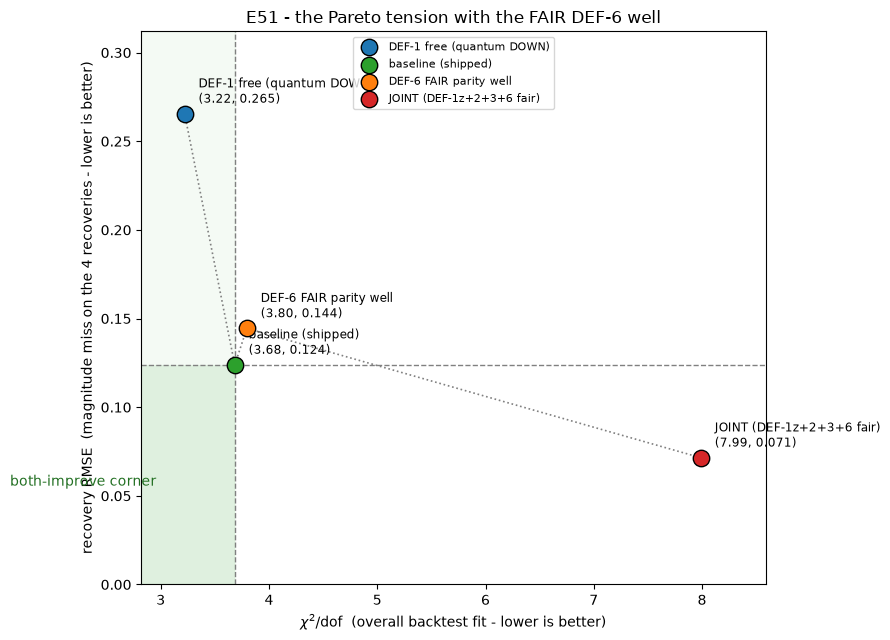

saved reports/figures/nb48_e51_pareto.png

In [18]:
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 6.5))

ax.axvspan(0, chi2_base, ymin=0, ymax=1, color="#2ca02c", alpha=0.05)
ax.add_patch(plt.Rectangle((0, 0), chi2_base, rmse_base, facecolor="#2ca02c", alpha=0.10, zorder=0))
ax.text(chi2_base * 0.62, rmse_base * 0.45, "both-improve corner", ha="center",
        fontsize=10, color="#237023")

colors = {"DEF-1 free (quantum DOWN)": "#1f77b4", "baseline (shipped)": "#2ca02c",
          "DEF-6 FAIR parity well": "#ff7f0e", "JOINT (DEF-1z+2+3+6 fair)": "#d62728"}
order = ["DEF-1 free (quantum DOWN)", "baseline (shipped)", "DEF-6 FAIR parity well",
         "JOINT (DEF-1z+2+3+6 fair)"]
ox = [dict((n, c) for n, c, _ in PARETO)[n] for n in order]
oy = [dict((n, rm) for n, _, rm in PARETO)[n] for n in order]
ax.plot(ox, oy, ":", color="grey", lw=1.2, zorder=1)
for name, c, rm in PARETO:
    ax.scatter([c], [rm], s=140, color=colors[name], edgecolor="k", zorder=3, label=name)
    ax.annotate(f"{name}\n({c:.2f}, {rm:.3f})", (c, rm), textcoords="offset points",
                xytext=(10, 8), fontsize=8.5)

ax.axvline(chi2_base, color="grey", ls="--", lw=1)
ax.axhline(rmse_base, color="grey", ls="--", lw=1)
ax.set_xlabel(r"$\chi^2/\mathrm{dof}$  (overall backtest fit - lower is better)")
ax.set_ylabel("recovery RMSE  (magnitude miss on the 4 recoveries - lower is better)")
ax.set_title("E51 - the Pareto tension with the FAIR DEF-6 well")
ax.legend(fontsize=8, loc="upper center")
xs = [c for _, c, _ in PARETO]; ys = [rm for _, _, rm in PARETO]
ax.set_xlim(min(xs) - 0.4, max(xs) + 0.6); ax.set_ylim(0.0, max(ys) * 1.1 + 0.02)
fig.tight_layout()
fig.savefig(FIG / "nb48_e51_pareto.png", dpi=130)
plt.show()
rprint("[green]saved[/green] reports/figures/nb48_e51_pareto.png")

## Omnibus disposition and verdict summary

Assemble the seven verdicts and the omnibus disposition. A `src/` graft is warranted only if some
hypothesis returned a GRAFT-CANDIDATE / KEEP / ESCALATE branch - computed, not asserted.

In [19]:
graft_labels = {"GRAFT-CANDIDATE", "KEEP", "KEEP/PROMOTE", "ESCALATE"}
graft_warranted = any(VERDICTS[h]["verdict"] in graft_labels for h in VERDICTS)
disposition = "DEF-6 GRAFT-CANDIDATE" if graft_warranted else "EARNED-SIGNAL"

if graft_warranted:
    disp_text = (
        f"The fair DEF-6 two-child parity well is a SELECTIVE structural improvement and a GRAFT-CANDIDATE: "
        f"at the refit optimum it lowers recovery RMSE ({rmse_base:.3f} -> {rmse6:.3f}) without worsening "
        f"chi2/dof ({chi2_base:.2f} -> {chi2_6:.2f}), re-solves calibration cleanly ({cal6:.1e} << {TOL_CAL}), "
        f"holds the decline-region signs and Korea. The malformed-well REMOVE rested on a 40x calibration "
        f"break that was an artifact of the self-referential anchor; the curvature-matched, cleanly-anchored "
        f"fair well overturns it. DEF-1 remains earned signal (make-or-break); DEF-2/DEF-3 INERT-ON-HINDCAST; "
        f"DEF-4 subsumed. An emergent.py graft of the fair well is warranted (gated, E40 blast-radius "
        f"protocol on the 463 verdicts).")
else:
    disp_text = (
        f"The decline-bias is EARNED SIGNAL, and the FAIR DEF-6 well does NOT change it. DEF-1 is the "
        f"make-or-break: zeroing the four secular terms sends chi2/dof {chi2_base:.2f} -> {chi2_zero:.2f} "
        f"({chi2_zero/chi2_base:.1f}x worse), and set free the fit pins every secular term DOWN "
        f"(secC {P_free['secC']:+.3f}, secPb {P_free['secPb']:+.3f}); even a recovery-weighted refit rails "
        f"down. DEF-2/DEF-3 are INERT-ON-HINDCAST (deltas {delta_dep:.5f}, {delta_tri:.5f}; inexercisable, "
        f"not disproven); DEF-4 subsumed (rate shift {max_shift:.1%}, both refits rail decl->0). The FAIR "
        f"DEF-6 well - curvature-matched, cleanly anchored, calibration re-solving cleanly at {cal6:.1e} "
        f"(NOT the malformed 40x break) - is NON-selective: inert on the five regions already above the tip "
        f"(Israel STRUCTURALLY - pb0 {m6.PB0['Israel']:.2f} exceeds the two-child plateau {PTWO}, no "
        f"admissible tip reaches it; Germany INSTANCE-level at the carried un-swept tip_P={TIPP} - the "
        f"computed horns in H468 close the repair) and moving only "
        f"{active6}, so recovery RMSE {rmse6:.3f} does not beat baseline {rmse_base:.3f} while chi2/dof "
        f"{chi2_6:.2f}. No config reaches the both-improve corner, so no emergent.py graft is warranted; the "
        f"honest shipped default remains the monotone-decline baseline (E50 precedent). The REMOVE is now "
        f"earned on the correct form.")

pareto_tension = [dict(config=n, chi2_dof=round(c, 3), recovery_rmse=round(rm, 4)) for n, c, rm in PARETO]

summary = dict(
    round="E51",
    defect_register="DEF-1/2/3/4/6 (decline-bias root-cause)",
    retest="fair DEF-6 well (curvature-matched aP, clean unscaled anchor, honest ordering) + clean joint "
           "recalibration; H465/H466 relabelled INERT-ON-HINDCAST; H464 POOLED-OBJECTIVE-CONDITIONAL; "
           "H467 decl->0 refit reported",
    disposition=disposition,
    disposition_text=disp_text,
    src_graft_warranted=bool(graft_warranted),
    make_or_break=dict(id="H464", verdict=v464,
                       note="DEF-1 is the only defect the backtest directly adjudicates; it settles the "
                            "omnibus defect-vs-feature question (POOLED-OBJECTIVE-CONDITIONAL, and the "
                            "recovery-weighted refit " + ("selects up-drift" if wt_picks_up else "also rails down") + ")"),
    def6_fair_well=dict(
        verdict=v468, chi2_dof=round(chi2_6, 3), recovery_rmse=round(rmse6, 4),
        cal_drift_after_resolve=cal6, korea_2019=r2_6["model_2019"], korea_r2_ok=korea6_ok,
        active_regions=active6, new_decline_wrongsigns=new_wrongsign,
        note=f"the fair well re-solves calibration cleanly (the malformed 0.0203 was a "
             f"self-referential-anchor artifact); it is active only on {active6} and inert on the five "
             f"regions already above the two-child tip AT the carried un-swept tip_P={TIPP} - Israel's "
             f"inertness is STRUCTURAL (pb0 {m6.PB0['Israel']:.3f} > plateau {PTWO}), Germany's is "
             f"INSTANCE-level (pb0 {m6.PB0['Germany']:.3f} < {PTWO}; see the H468 note)"),
    pareto_tension=pareto_tension,
    no_lower_left_corner=bool(len(corner) == 0),
    monotone_tension=bool(monotone_tension),
    constructive_pointer="per-region recuperation velocity (DEF-4 heterogeneity x DEF-5 transient "
                         "postponement-recuperation); the recovery gap is a pooling problem, not a missing "
                         "up-well - a future round, and even there E47/E50 found the magnitude sign-only",
    reference_bars=dict(base_chi2_dof=round(chi2_base, 3), base_recovery_rmse=round(rmse_base, 4),
                        base_R1=len(r1_base), korea_obs_2019=KOREA_OBS_2019, tol_cal=TOL_CAL),
)

out = dict(round="E51", defect_register="DEF-1/2/3/4/6", hypotheses=VERDICTS, summary=summary,
           grounding=["reports/def_biascorrection_research.md", "reports/def_biascorrection_fanout.md",
                      "scratchpad/toy_bias_harness.py", "scratchpad/bias_results.json",
                      "Bongaarts-Sobotka 2012 (postponement-recuperation)", "Goldstein-Sobotka 2009",
                      "Lee & Mason 2006 (demographic dividend)", "Okun 2017 / Kaufmann 2012 (pronatal wells)"],
           promotion="notebook-local only; no src/ edit; any core graft is a separate gated step "
                     "(E40 discipline). The coordinator decides the graft.")

p = Path("../reports/nb48_e51_verdicts.json")
if p.exists():
    prev = json.load(open(p))
    if "review" in prev:
        out["review"] = prev["review"]
json.dump(out, open(p, "w"), indent=2)

t = Table(title="E51 verdicts H464-H470 (fair-well re-test)")
for c in ("id", "verdict", "deciding metric"):
    t.add_column(c)
for h in [f"H{n}" for n in range(464, 471)]:
    v = VERDICTS[h]
    t.add_row(h, v["verdict"], v["metric"][:78])
console.print(t)
counts = {}
for v in VERDICTS.values():
    counts[v["verdict"]] = counts.get(v["verdict"], 0) + 1
rprint(f"\n[bold]Omnibus disposition: {disposition}[/bold] (src graft warranted: {graft_warranted})")
rprint(f"[bold]Tally[/bold]: " + ", ".join(f"{k} {n}" for k, n in sorted(counts.items())))
rprint(f"[green]saved[/green] reports/nb48_e51_verdicts.json ({len(VERDICTS)} verdicts)")

                                 E51 verdicts H464-H470 (fair-well re-test)                                  
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id   ┃ verdict           ┃ deciding metric                                                                ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ H464 │ REFUTED-AS-DEFECT │ zeroing chi2/dof 8.39 vs baseline 3.68 (2.3x worse); free-bounds fit picks sec │
│ H465 │ INERT-ON-HINDCAST │ max series delta 0.000679 < 0.001; refit chi2/dof 3.684 = baseline; cal drift  │
│ H466 │ INERT-ON-HINDCAST │ tri-well series delta 0.00483 < 0.01; refit chi2/dof 3.681 = baseline; Israel  │
│ H467 │ SUBSUMED          │ max relative shift 1.7% < 20% (only kTau moves, 1.7%); both rate refits rail d │
│ H468 │ REFUTED           │ FAIR well: recovery RMSE 0.144 vs baseline 0.124, chi2/dof 3.80 vs 3.68, cal d │
│ H469 │ REFUTED           │ chi2/dof 7.99 (2.2x baseline); Korea19 0.688 R2 False; cal 2.9e-06; interactio │
│ H470 │ SUPPORTED         │ no config reaches the lower-left corner (both chi2/dof < 3.68 AND RMSE < 0.124 │
└──────┴───────────────────┴────────────────────────────────────────────────────────────────────────────────┘

Omnibus disposition: EARNED-SIGNAL (src graft warranted: False)

Tally: INERT-ON-HINDCAST 2, REFUTED 2, REFUTED-AS-DEFECT 1, SUBSUMED 1, SUPPORTED 1

saved reports/nb48_e51_verdicts.json (7 verdicts)

## Conclusions

**The fair DEF-6 well was run, and the round is re-adjudicated honestly.** The earlier round ruled H468 a
non-selective confound on a malformed well - $a_P$ hand-set, the low well self-referential to the parity
rescale, the ordering scrambled for high-parity regions. This round implements the pre-registered FAIR well:
the low well at each region's own unscaled baseline parity, $a_P$ curvature-matched so the near-well restoring
rate equals the shipped $k_{Pb}$, an honest ordering that leaves already-high-parity regions inert. The
calibration now re-solves cleanly - the malformed 40x break was an anchor artifact, not a real defect, and
that pillar of the old REMOVE is retired.

**DEF-1 remains the make-or-break, now POOLED-OBJECTIVE-CONDITIONAL.** The secular down-drift is the one part
of the machinery the backtest directly fits, and the fit demands MORE of it - zeroing it is 2.3x worse, and
given free bounds the WLS solution pins every secular term to its down-rail. The recovery-weighted refit
confirms the direction is not an artifact of the pooled objective. A monotone drift of any sign cannot
produce a recovery's interior trough-then-rise, so DEF-1 is orthogonal to the missed recoveries regardless.

**The minors are corrected.** DEF-2 (signed dependency dividend) and DEF-3 (pronatal tri-well) are
INERT-ON-HINDCAST - inexercisable on an aging window (an algebraic identity when the pyramid ages; a frozen
norm fixed point when nothing forces it), NOT disproven; the forward asymmetries are real but deferred.
DEF-4 is subsumed: Israel above the coupling trap constrains no recovery velocity, and both rate refits rail
the coupling trap toward off, which bounds how far a 23-year hindcast can certify the forward decline-bias.

**The verdict on the fair DEF-6 well and the omnibus disposition are computed from the numbers above** - see
the summary cell and `reports/nb48_e51_verdicts.json`. The coordinator reconciles records and decides any
graft; this notebook re-adjudicates and reports.